In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.filters
import skimage.morphology
import scipy.ndimage
from scipy.interpolate import interp1d
from scipy.stats import linregress

In [40]:
def cropping(image, x_pixel = 1500):
    N = int(np.shape(image)[1])
    cropped_image = image[60:300, N // 2-x_pixel // 2 : N // 2 + x_pixel // 2]
    
    return cropped_image

def contrast_stretching(image):
    min_val = np.min(image)
    max_val = np.max(image)
    normalized = (image - min_val) / (max_val - min_val)
    contrasted_image = np.uint8(255 * normalized)

    return contrasted_image

def image_thesholding(image):
    threshold = skimage.filters.threshold_otsu(image)
    thresholded_image = image > threshold
    
    return thresholded_image

def opened_image(image, disk = 2):
    image_opening = scipy.ndimage.binary_opening(image, structure=skimage.morphology.disk(disk))
    
    return image_opening

def small_obj_removal(image, obj_size = 500):
    image_smallobjsremoved = skimage.morphology.remove_small_objects(image, min_size=obj_size)
    
    return image_smallobjsremoved

def find_rawsurface(image):
    surface_raw = []
    for col in range(np.shape(image_smallobjs)[1]):

        index = np.where(image_smallobjs[:, col] == 1)[0]
        if len(index)!=0:
            surface_raw.append(index[0])
        else:
            surface_raw.append(np.nan)
            
    return surface_raw

def median_raw_surface(image, median_th = 10):
    smoothed_surface = scipy.ndimage.median_filter(surface_raw, size= median_th)
    
    return smoothed_surface

def remove_outliers(surface, outlier_th = 2):
    diffs = np.abs(np.diff(surface))
    bad = np.where(diffs > outlier_th)[0] + 1
    surface[bad] = np.nan
    
    return surface

def interpolation(surface, degree=2, sigma = 3, max_gap=10):
    x = np.arange(len(surface))
    surface = np.array(surface, dtype=float)  # Ensure it's float for NaNs

    isnan = np.isnan(surface)
    notnan = ~isnan

    if np.sum(notnan) < 3:
        return surface  # Not enough points for reliable interpolation

    # Interpolate only small NaN gaps
    i = 0
    while i < len(surface):
        if np.isnan(surface[i]):
            start = i - 1
            while i < len(surface) and np.isnan(surface[i]):
                i += 1
            end = i  # now surface[end] is the first non-NaN after the gap

            # Check if interpolation is valid and gap is small enough
            if start >= 1 and end < len(surface) - 1 and (end - start - 1) <= max_gap:
                x_fit = [x[start - 1], x[start], x[end]]
                y_fit = [surface[start - 1], surface[start], surface[end]]

                coeffs = np.polyfit(x_fit, y_fit, degree)
                poly = np.poly1d(coeffs)

                surface[start + 1:end] = poly(x[start + 1:end])
        else:
            i += 1
    
    # Find longest contiguous non-NaN segment
    isnan = np.isnan(surface)
    max_len = 0
    max_start = 0
    i = 0
    while i < len(surface):
        if not isnan[i]:
            start = i
            while i < len(surface) and not isnan[i]:
                i += 1
            length = i - start
            if length > max_len:
                max_len = length
                max_start = start
        else:
            i += 1

    # Mask everything except longest contiguous surface
    keep = np.full_like(surface, np.nan)
    keep[max_start:max_start + max_len] = surface[max_start:max_start + max_len]

    # Final smoothing
    smoothed_interpolated = scipy.ndimage.gaussian_filter(keep, sigma=5)
    return smoothed_interpolated

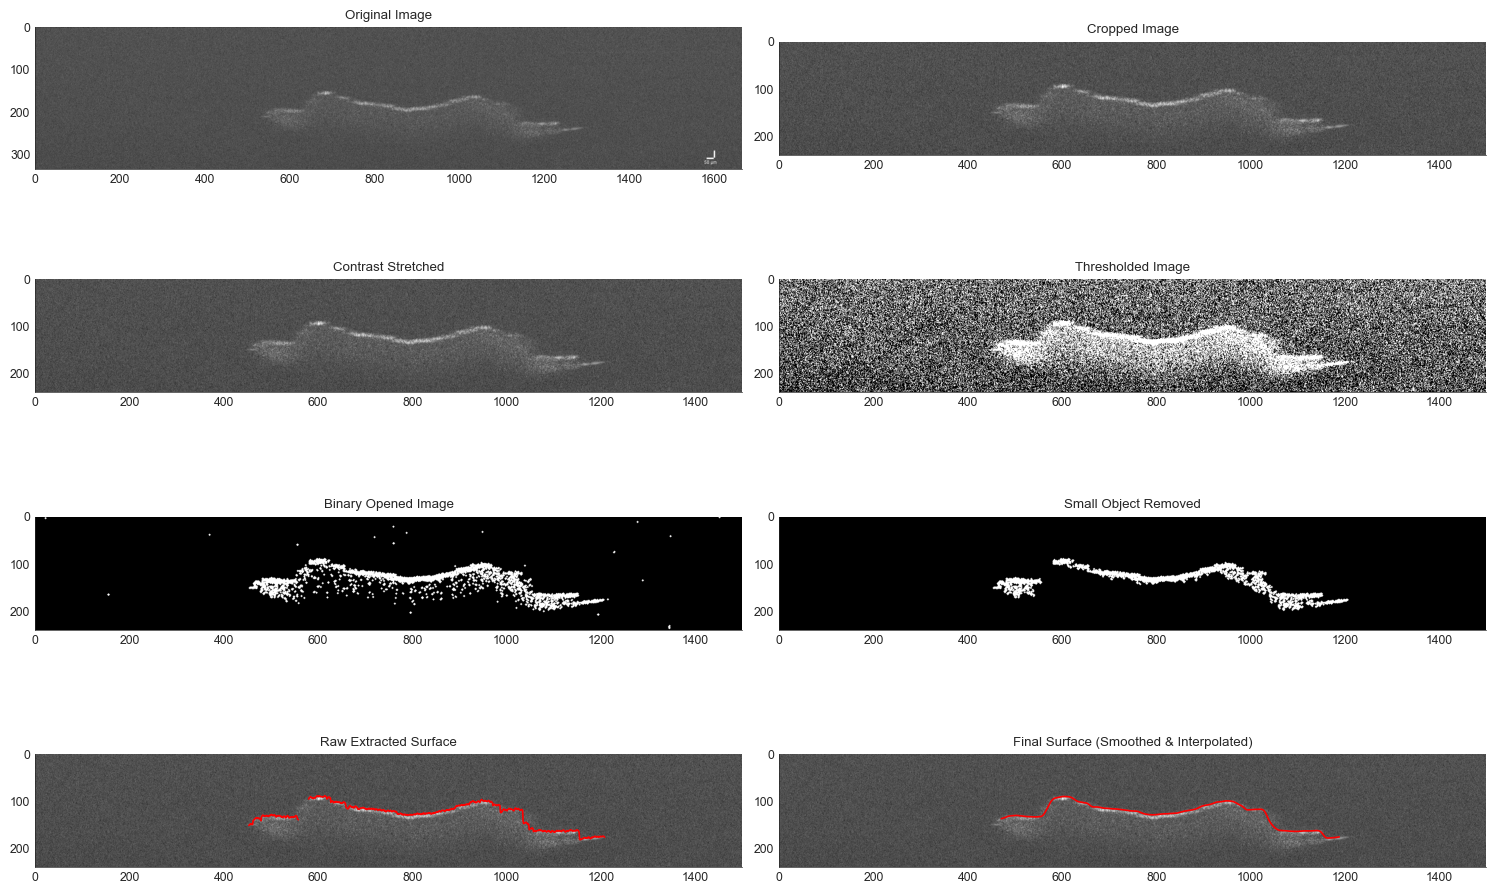

In [41]:
#testing

address = r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=1\Raw data\B7.tiff"
original_image = cv2.imread(address, cv2.IMREAD_GRAYSCALE)

# Processing steps
cropped_image = cropping(original_image, x_pixel=1500)

# Create subplots
fig, ax = plt.subplots(4, 2, figsize=(15, 10))
ax = ax.flatten()

# Display each stage
ax[0].imshow(original_image, cmap='gray')
ax[0].set_title("Original Image")

ax[1].imshow(cropped_image, cmap='gray')
ax[1].set_title("Cropped Image")

contrasted_image = contrast_stretching(cropped_image)

ax[2].imshow(contrasted_image, cmap='gray')
ax[2].set_title("Contrast Stretched")

thresholded_image = image_thesholding(contrasted_image)

ax[3].imshow(thresholded_image, cmap='gray')
ax[3].set_title("Thresholded Image")

image_opening = opened_image(thresholded_image, disk=2)

ax[4].imshow(image_opening, cmap='gray')
ax[4].set_title("Binary Opened Image")

image_smallobjs = small_obj_removal(image_opening, obj_size = 300)

ax[5].imshow(image_smallobjs, cmap='gray')
ax[5].set_title("Small Object Removed")

surface_raw = find_rawsurface(image_smallobjs)

# Overlay raw surface on contrasted image
ax[6].imshow(contrasted_image, cmap='gray')
ax[6].plot(surface_raw, color='red')
ax[6].set_title("Raw Extracted Surface")

smoothed_surface = median_raw_surface(surface_raw, median_th = 5)
outlierremoved_surface = remove_outliers(smoothed_surface, outlier_th = 2)
interpolated_surface = interpolation(outlierremoved_surface, degree = 1, sigma = 20, max_gap = 100)

# Overlay final interpolated surface
ax[7].imshow(contrasted_image, cmap='gray')
ax[7].plot(interpolated_surface, color='red')
ax[7].set_title("Final Surface (Smoothed & Interpolated)")


plt.tight_layout()
plt.show()


In [42]:
surfaces_1 = []
for i in range(1, 26):
    address = r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=1\Raw data\B"+str(i)+".tiff"
    original_image = cv2.imread(address, cv2.IMREAD_GRAYSCALE)
    if 9 <= i <= 13:
        max_gap = 500
        sigma = 50
    else:
        max_gap = 80
        sigma = 5
        
    if i==24 or i==25 or i==16:
        obj_size = 500
    else:
        obj_size = 100
        
    cropped_image = cropping(original_image, x_pixel=1500)
    contrasted_image = contrast_stretching(cropped_image)
    thresholded_image = image_thesholding(contrasted_image)
    
    image_opening = opened_image(thresholded_image, disk=2)
    image_smallobjs = small_obj_removal(image_opening, obj_size = obj_size)
    surface_raw = find_rawsurface(image_smallobjs)
    smoothed_surface = median_raw_surface(surface_raw, median_th = 5)
    outlierremoved_surface = remove_outliers(smoothed_surface, outlier_th = 2)
    interpolated_surface = interpolation(outlierremoved_surface, degree = 1, sigma = sigma, max_gap = max_gap)

    surfaces_1.append(np.array(interpolated_surface))
    
surfaces_2 = []
for i in range(1,26):
    address = r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=2\Raw data\B"+str(i)+".tiff"
    original_image = cv2.imread(address, cv2.IMREAD_GRAYSCALE)
    if 9 <= i <= 13:
        max_gap = 500
        sigma = 20
    else:
        max_gap = 100
        sigma = 5
        
    if i==24 or i==25:
        obj_size = 500
    else:
        obj_size = 100
        
    cropped_image = cropping(original_image, x_pixel=1500)
    contrasted_image = contrast_stretching(cropped_image)
    thresholded_image = image_thesholding(contrasted_image)
    
    image_opening = opened_image(thresholded_image, disk=2)
    image_smallobjs = small_obj_removal(image_opening, obj_size = obj_size)
    surface_raw = find_rawsurface(image_smallobjs)
    smoothed_surface = median_raw_surface(surface_raw, median_th = 5)
    outlierremoved_surface = remove_outliers(smoothed_surface, outlier_th = 2)
    interpolated_surface = interpolation(outlierremoved_surface, degree = 1, sigma = sigma, max_gap = max_gap)
    
    surfaces_2.append(np.array(interpolated_surface))
    
surfaces_3 = []
for i in range(1,26):
    address = r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=3\Raw data\B"+str(i)+".tiff"
    original_image = cv2.imread(address, cv2.IMREAD_GRAYSCALE)
    if 9 <= i <= 13:
        max_gap = 500
        sigma = 20
    else:
        max_gap = 100
        sigma = 5
    cropped_image = cropping(original_image, x_pixel=1500)
    contrasted_image = contrast_stretching(cropped_image)
    thresholded_image = image_thesholding(contrasted_image)
    
    image_opening = opened_image(thresholded_image, disk=2)
    image_smallobjs = small_obj_removal(image_opening, obj_size = 100)
    surface_raw = find_rawsurface(image_smallobjs)
    smoothed_surface = median_raw_surface(surface_raw, median_th = 5)
    outlierremoved_surface = remove_outliers(smoothed_surface, outlier_th = 2)
    interpolated_surface = interpolation(outlierremoved_surface, degree = 1, sigma = sigma, max_gap = max_gap)

    surfaces_3.append(np.array(interpolated_surface))


In [43]:
q_1 = []
m_1 = []
surface_array_1 = []
for i in range(25):
    arr = surfaces_1[i]
    
    # Center surface
    valid = ~np.isnan(arr)
    first = np.argmax(valid)
    last = len(arr) - np.argmax(valid[::-1]) - 1
    segment = arr[first:last+1]

    new_arr = np.full_like(arr, np.nan)
    start = (len(arr) - len(segment)) // 2
    new_arr[start:start + len(segment)] = segment
    surface = 240 - new_arr

    # Prepare for detrending
    surface_valid = ~np.isnan(surface)
    x = np.arange(len(surface))
    x_valid = x[surface_valid]
    y_valid = surface[surface_valid]

    if len(y_valid) >= 3:
        if i not in [0,11,12,13,14,15,24]:
            #fix tilt in wrinkled biofilms
            p = np.polyfit(x_valid, y_valid, deg=1)
        else:
             #fix agarose curvature in flat biofilms
            p = np.polyfit(x_valid, y_valid, deg=2)
        baseline = np.polyval(p, x_valid)
        surface[surface_valid] = y_valid - baseline
   
    surface = surface-np.nanmin(surface)
    surface_array_1.append(surface)
    if i == 4:
        profile_WT = surface
    q_1.append(np.nanmax(surface))
    m_1.append(np.nanmean(surface))
# np.savetxt(r'C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=1\N=1 surfaces.txt', surface_array_1, fmt='%.4f', delimiter=',')

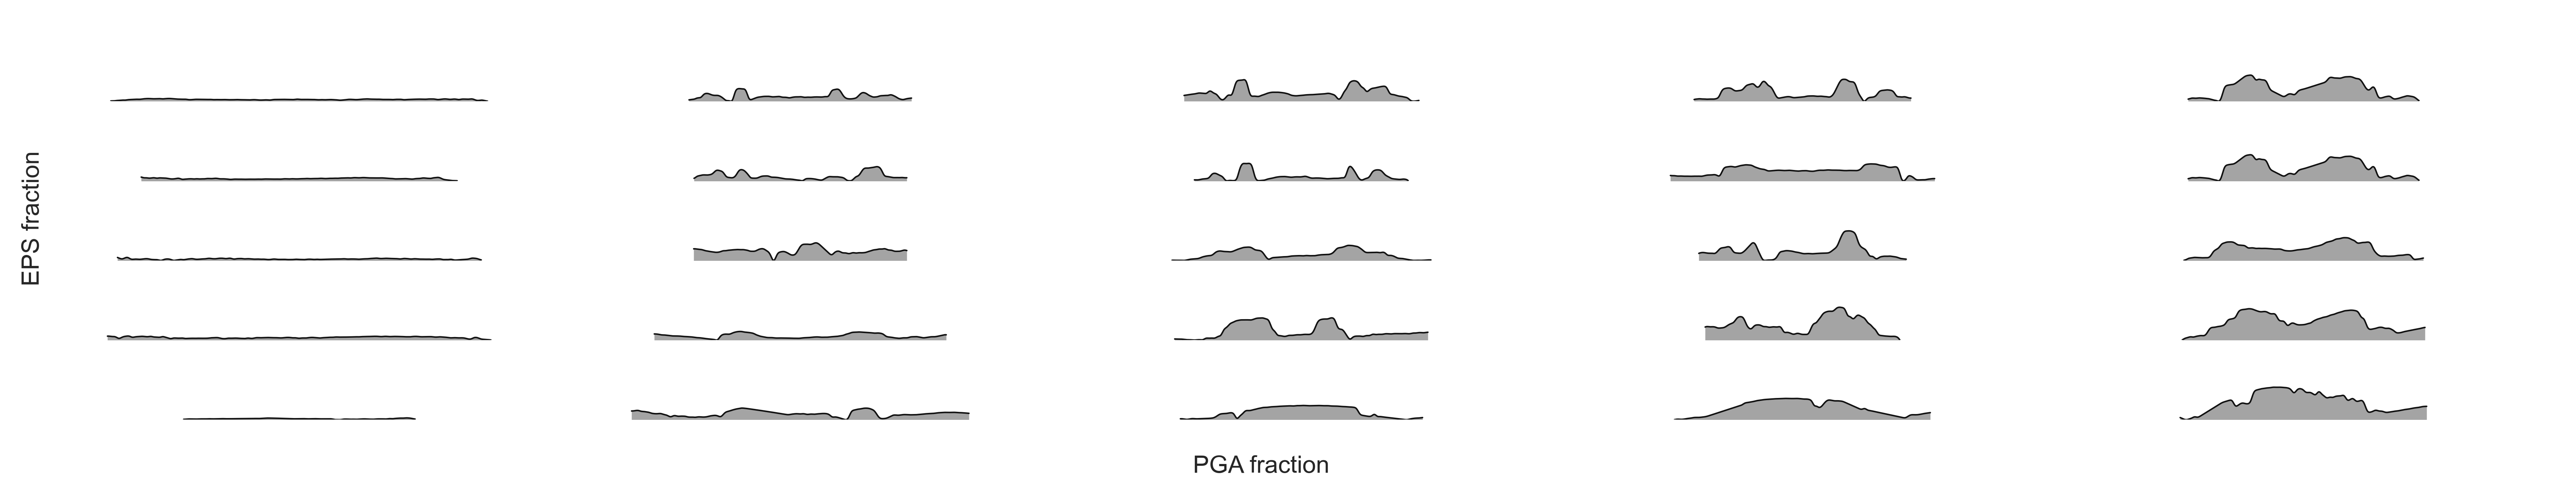

In [44]:
# Assume surface_array_1 is a list of 25 1D array_1s
import seaborn as sns
sns.set_style("white")
sns.set_context("paper", font_scale=1)
surface_mat_1 = np.empty((5, 5), dtype=object)

# Custom spiral mapping of surface_array_1 into surface_mat_1
surface_mat_1[0, :] = surface_array_1[0:5]
surface_mat_1[1:5, 4] = surface_array_1[5:9]
surface_mat_1[4, 0:4] = surface_array_1[9:13][::-1]
surface_mat_1[1:4, 0] = surface_array_1[13:16][::-1]
surface_mat_1[1, 3] = surface_array_1[16]
surface_mat_1[2, 2] = surface_array_1[17]
surface_mat_1[3, 1] = surface_array_1[18]
surface_mat_1[1, 1] = surface_array_1[19]
surface_mat_1[3, 3] = surface_array_1[20]
surface_mat_1[1, 2] = surface_array_1[21]
surface_mat_1[2, 3] = surface_array_1[22]
surface_mat_1[3, 2] = surface_array_1[23]
surface_mat_1[2, 1] = surface_array_1[24]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 8,
    "axes.linewidth": 0.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
fig, axs = plt.subplots(5, 5, figsize=((7.5 * 5) / 2.54, (1.2 * 5) / 2.54), dpi=600)
fill_color = "#676767"  # Soft light gray
line_color = "#111111"  # Dark gray

for i in range(5):
    for j in range(5):
        ax = axs[i, j]
        ax.axis('off')

        surf = surface_mat_1[i, j]
        if surf is not None:
            valid_mask = ~np.isnan(surf)
            if np.sum(valid_mask) > 1:
                x_all = np.arange(len(surf))
                x_valid = x_all[valid_mask]
                y_valid = surf[valid_mask]

                first_idx = x_valid[0]
                last_idx = x_valid[-1]

                x = np.arange(first_idx, last_idx + 1)
                y = surf[first_idx:last_idx + 1]

                if np.all(np.isnan(y)):
                    continue

                # Normalize
                y = y - np.nanmin(y)

                # Constant baseline 10 below min y
                baseline_value = np.nanmin(y) - 10
                raw_baseline = np.full_like(y, baseline_value)
                baseline = np.minimum(raw_baseline, y)

                ax.fill_between(x, y, baseline, where=(baseline < y), 
                                color=fill_color, alpha=0.6, linewidth=0)
                ax.plot(x, y, color=line_color, linewidth=0.5)

                ax.set_xlim(0, 1500)
                ax.set_ylim(0, 240)

                # Remove ticks, but keep precise limits
                ax.set_xticks([])
                ax.set_yticks([])

fig.text(0.5, 0.02, "PGA fraction", ha='center', va='center', fontsize=8)
fig.text(0.12, 0.5, "EPS fraction", ha='center', va='center', rotation='vertical', fontsize=8)

plt.subplots_adjust(wspace=0, hspace=0)

# plt.savefig(
#     r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=1\Consolidated surface profile.svg",
#     format='svg',
#     bbox_inches='tight',
#     pad_inches=0
# )
plt.show()

In [45]:
q_2 = []
m_2 = []
surface_array_2 = []
for i in range(25):
    arr = surfaces_2[i]

    # Center surface
    valid = ~np.isnan(arr)
    first = np.argmax(valid)
    last = len(arr) - np.argmax(valid[::-1]) - 1
    segment = arr[first:last+1]

    new_arr = np.full_like(arr, np.nan)
    start = (len(arr) - len(segment)) // 2
    new_arr[start:start + len(segment)] = segment
    surface = 240 - new_arr

    # Prepare for detrending
    surface_valid = ~np.isnan(surface)
    x = np.arange(len(surface))
    x_valid = x[surface_valid]
    y_valid = surface[surface_valid]

    if len(y_valid) >= 3:
        if i not in [0,11,12,13,14,15, 24]:
            #fix tilt in wrinkled biofilms
            p = np.polyfit(x_valid, y_valid, deg=1)
        else:
             #fix agarose curvature in flat biofilms
            p = np.polyfit(x_valid, y_valid, deg=2)
        baseline = np.polyval(p, x_valid)
        surface[surface_valid] = y_valid - baseline
   
    surface = surface-np.nanmin(surface)
    surface_array_2.append(surface)
    q_2.append(np.nanmax(surface))
    m_2.append(np.nanmean(surface))
# np.savetxt(r'C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=2\N=2 surfaces.txt', surface_array_2, fmt='%.4f', delimiter=',')

In [46]:
q_3 = []
m_3 = []
surface_array_3 = []
for i in range(25):
    arr = surfaces_3[i]

    # Center surface
    valid = ~np.isnan(arr)
    first = np.argmax(valid)
    last = len(arr) - np.argmax(valid[::-1]) - 1
    segment = arr[first:last+1]

    new_arr = np.full_like(arr, np.nan)
    start = (len(arr) - len(segment)) // 2
    new_arr[start:start + len(segment)] = segment
    surface = 240 - new_arr

    # Prepare for detrending
    surface_valid = ~np.isnan(surface)
    x = np.arange(len(surface))
    x_valid = x[surface_valid]
    y_valid = surface[surface_valid]

    if len(y_valid) >= 3:
        if i not in [0,11,12,13,14,15, 24]:
            #fix tilt in wrinkled biofilms
            p = np.polyfit(x_valid, y_valid, deg=1)
        else:
             #fix agarose curvature in flat biofilms
            p = np.polyfit(x_valid, y_valid, deg=2)
        baseline = np.polyval(p, x_valid)
        surface[surface_valid] = y_valid - baseline
   
    surface = surface-np.nanmin(surface)
    surface_array_3.append(surface)
    q_3.append(np.nanmax(surface))
    m_3.append(np.nanmean(surface))
# np.savetxt(r'C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0825\F0825 OCT data\N=3\N=3 surfaces.txt', surface_array_3, fmt='%.4f', delimiter=',')


In [47]:
q_1_mat = np.zeros((5, 5))

q_1_mat[0, :] = q_1[0:5]
q_1_mat[1:5, 4] = q_1[5:9]
q_1_mat[4, 0:4] = q_1[9:13][::-1]
q_1_mat[1:4, 0] = q_1[13:16][::-1]
q_1_mat[1, 3] = q_1[16]
q_1_mat[2, 2] = q_1[17]
q_1_mat[3, 1] = q_1[18]
q_1_mat[1, 1] = q_1[19]
q_1_mat[3, 3] = q_1[20]
q_1_mat[1, 2] = q_1[21]
q_1_mat[2, 3] = q_1[22]
q_1_mat[3, 2] = q_1[23]
q_1_mat[2, 1] = q_1[24]

m_1_mat = np.zeros((5, 5))

m_1_mat[0, :] = m_1[0:5]
m_1_mat[1:5, 4] = m_1[5:9]
m_1_mat[4, 0:4] = m_1[9:13][::-1]
m_1_mat[1:4, 0] = m_1[13:16][::-1]
m_1_mat[1, 3] = m_1[16]
m_1_mat[2, 2] = m_1[17]
m_1_mat[3, 1] = m_1[18]
m_1_mat[1, 1] = m_1[19]
m_1_mat[3, 3] = m_1[20]
m_1_mat[1, 2] = m_1[21]
m_1_mat[2, 3] = m_1[22]
m_1_mat[3, 2] = m_1[23]
m_1_mat[2, 1] = m_1[24]

q_2_mat = np.zeros((5, 5))

q_2_mat[0, :] = q_2[0:5]
q_2_mat[1:5, 4] = q_2[5:9]
q_2_mat[4, 0:4] = q_2[9:13][::-1]
q_2_mat[1:4, 0] = q_2[13:16][::-1]
q_2_mat[1, 3] = q_2[16]
q_2_mat[2, 2] = q_2[17]
q_2_mat[3, 1] = q_2[18]
q_2_mat[1, 1] = q_2[19]
q_2_mat[3, 3] = q_2[20]
q_2_mat[1, 2] = q_2[21]
q_2_mat[2, 3] = q_2[22]
q_2_mat[3, 2] = q_2[23]
q_2_mat[2, 1] = q_2[24]

m_2_mat = np.zeros((5, 5))

m_2_mat[0, :] = m_2[0:5]
m_2_mat[1:5, 4] = m_2[5:9]
m_2_mat[4, 0:4] = m_2[9:13][::-1]
m_2_mat[1:4, 0] = m_2[13:16][::-1]
m_2_mat[1, 3] = m_2[16]
m_2_mat[2, 2] = m_2[17]
m_2_mat[3, 1] = m_2[18]
m_2_mat[1, 1] = m_2[19]
m_2_mat[3, 3] = m_2[20]
m_2_mat[1, 2] = m_2[21]
m_2_mat[2, 3] = m_2[22]
m_2_mat[3, 2] = m_2[23]
m_2_mat[2, 1] = m_2[24]

q_3_mat = np.zeros((5, 5))

q_3_mat[0, :] = q_3[0:5]
q_3_mat[1:5, 4] = q_3[5:9]
q_3_mat[4, 0:4] = q_3[9:13][::-1]
q_3_mat[1:4, 0] = q_3[13:16][::-1]
q_3_mat[1, 3] = q_3[16]
q_3_mat[2, 2] = q_3[17]
q_3_mat[3, 1] = q_3[18]
q_3_mat[1, 1] = q_3[19]
q_3_mat[3, 3] = q_3[20]
q_3_mat[1, 2] = q_3[21]
q_3_mat[2, 3] = q_3[22]
q_3_mat[3, 2] = q_3[23]
q_3_mat[2, 1] = q_3[24]

m_3_mat = np.zeros((5, 5))

m_3_mat[0, :] = m_3[0:5]
m_3_mat[1:5, 4] = m_3[5:9]
m_3_mat[4, 0:4] = m_3[9:13][::-1]
m_3_mat[1:4, 0] = m_3[13:16][::-1]
m_3_mat[1, 3] = m_3[16]
m_3_mat[2, 2] = m_3[17]
m_3_mat[3, 1] = m_3[18]
m_3_mat[1, 1] = m_3[19]
m_3_mat[3, 3] = m_3[20]
m_3_mat[1, 2] = m_3[21]
m_3_mat[2, 3] = m_3[22]
m_3_mat[3, 2] = m_3[23]
m_3_mat[2, 1] = m_3[24]

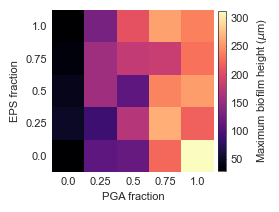

In [48]:
scale = 999.72 / 334
max_height_map = np.mean([q_1_mat, q_2_mat, q_3_mat], axis=0) * scale
max_height_map_std = np.std([q_1_mat, q_2_mat, q_3_mat], axis=0) * scale

fig, ax = plt.subplots(figsize=(2.8, 2.4))  
cmap = plt.cm.magma
im = ax.imshow(max_height_map, cmap=cmap, origin="upper")
ax.set_ylabel("EPS fraction", fontsize=8)
ax.set_xlabel("PGA fraction", fontsize=8)
ticks = [0, 1, 2, 3, 4]
tick_labels = [0.0, 0.25, 0.5, 0.75, 1.0]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels[::-1], fontsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)

cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cb.set_label(r"Maximum biofilm height ($\mu$m)", fontsize=8)
cb.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

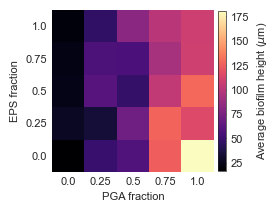

In [49]:
scale = 999.72 / 334
mean_height_map = np.mean([m_1_mat, m_2_mat, m_3_mat], axis=0) * scale
mean_height_map_std = np.std([m_1_mat, m_2_mat, m_3_mat], axis=0) * scale

fig, ax = plt.subplots(figsize=(2.8, 2.4))  
cmap = plt.cm.magma
im = ax.imshow(mean_height_map, cmap=cmap, origin="upper")
ax.set_ylabel("EPS fraction", fontsize=8)
ax.set_xlabel("PGA fraction", fontsize=8)
ticks = [0, 1, 2, 3, 4]
tick_labels = [0.0, 0.25, 0.5, 0.75, 1.0]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_yticks(ticks)
ax.set_yticklabels(tick_labels[::-1], fontsize=8)
for spine in ax.spines.values():
    spine.set_visible(False)

cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cb.set_label(r"Average biofilm height ($\mu$m)", fontsize=8)
cb.ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

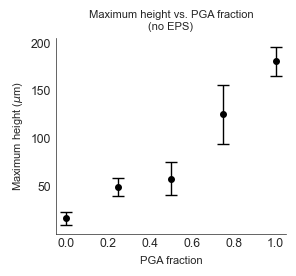

In [60]:
fig, ax = plt.subplots(figsize=(3, 2.8))  # Single-column size

# Data
x_axis = [0, 0.25, 0.5, 0.75, 1]
y_vals = mean_height_map[4, :]
y_errs = mean_height_map_std[4, :]

ax.errorbar(
    x_axis,
    y_vals,
    yerr=y_errs,
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1,
    capsize=4,
    markersize=4,
    linewidth=1,
)


ax.set_title("Maximum height vs. PGA fraction\n(no EPS)", fontsize=8)
ax.set_xlabel("PGA fraction", fontsize=8)
ax.set_ylabel(r"Maximum height ($\mu$m)", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
